# Regresión con PyCaret 4.0 — ¿cuánto costará asegurar a una persona?

Cuaderno didáctico de **aprendizaje automático supervisado para variables continuas**
(*regresión*). Construimos, paso a paso y justificando cada decisión, un modelo que
predice el **costo médico anual** de una póliza de seguro de salud.

Es el ejemplo clásico del tutorial *Introduction to Regression in Python with PyCaret*
y tiene una virtud didáctica enorme: **una sola variable (`smoker`) explica casi todo**,
lo que permite discutir con claridad qué aporta —y qué no— un modelo.

---

## Objetivos de aprendizaje

Al terminar el cuaderno serás capaz de:

1. **Describir** un conjunto de datos y decidir si el problema es de regresión.
2. **Configurar** un experimento de modelado (`RegressionExperiment`) con validación
   cruzada y preprocesamiento automático.
3. **Comparar** modelos con una sola instrucción y **leer** el ranking de métricas con
   criterio (no solo "el número más bajo").
4. **Ajustar** hiperparámetros, **ensamblar** modelos y **evaluar** en datos no vistos.
5. **Diagnosticar** el modelo con gráficos: residuos, error de predicción e importancia
   de variables.
6. **Predecir** casos nuevos, **guardar** el modelo y automatizar el proceso con `automl()`.

## Ruta de trabajo

| Sección | Qué haremos |
|---|---|
| 1 | Cargar y **entender** los datos (diccionario, perfil y gráficos) |
| 2 | Configurar el experimento |
| 3 | Comparar modelos (línea base) |
| 4 | Crear y ajustar el mejor modelo |
| 5 | Ensamblar modelos |
| 6 | Evaluar en el conjunto de prueba y analizar los errores |
| 7 | Predecir pólizas nuevas |
| 8 | Guardar y recuperar el modelo |
| 9 | Automatizar con `automl()` y `finalize_model()` |
| 10 | Resumen, equivalencias 3.x → 4.0 y errores conocidos |
| 11 | Ejercicio propuesto |

> **Cómo leer este cuaderno.** Cada sección tiene tres partes: (a) una **explicación**
> conceptual, (b) el **código comentado** y (c) una **interpretación de los
> resultados**, con los números que produce la ejecución. Los bloques marcados con 🔴
> señalan errores conocidos de la versión *alpha* que estamos usando.

---

### Requisitos

```bash
pip install "pycaret==4.0.0a8"     # o, para la última versión previa: pip install --pre pycaret
```

> **Aviso sobre las versiones 3.x y 4.0**
>
> PyCaret 3.x ofrecía una **API funcional** (`setup`, `compare_models`,
> `predict_model`, `save_model` como funciones sueltas del módulo).
> PyCaret **4.0 es OOP-only**: esos verbos viven en una clase `Experiment`
> (`RegressionExperiment`, `ClassificationExperiment`, `ClusteringExperiment`,
> `AnomalyExperiment`, `TimeSeriesExperiment`). La tabla de equivalencias está al
> final del cuaderno.
>
> Desde PyCaret 3.3 el paquete fija versiones antiguas de `numpy` (`<1.27`) y
> `pandas` (`<2.1`); la versión 4.0 exige `numpy>=1.26` y `pandas>=2.2`, por lo que
> convive sin problemas con `scikit-learn` moderno.
>
> **4.0 sigue en versión *alpha***: trae errores conocidos. Los encontrarás marcados
> con 🔴 a lo largo del cuaderno y resumidos en la última sección, para que no te
> cuesten una tarde.


## Diccionario de variables

El conjunto `insurance` contiene **1338 pólizas** con 7 columnas: 6 variables
explicativas (predictoras) y 1 variable objetivo.

| Variable | Tipo | Descripción | Unidad / valores | Papel |
|---|---|---|---|---|
| `age` | numérica (entera) | Edad del titular principal | 18 – 64 años | explicativa |
| `sex` | categórica | Sexo del titular | `female`, `male` | explicativa |
| `bmi` | numérica | Índice de masa corporal (IMC = peso / talla²) | ≈ 16 – 53 kg/m² | explicativa |
| `children` | numérica (entera) | Número de hijos cubiertos por la póliza | 0 – 5 | explicativa |
| `smoker` | categórica | ¿El titular fuma? | `yes`, `no` | explicativa |
| `region` | categórica | Región de residencia en EE. UU. | `northeast`, `northwest`, `southeast`, `southwest` | explicativa |
| `charges` | numérica | **Costo médico anual facturado** | ≈ 1 122 – 63 770 USD | **objetivo** |

**Lectura clave del diccionario:** `charges` es una cantidad *continua* (dólares), no una
etiqueta. Por eso hablamos de **regresión** y de *error* (en dólares), no de aciertos ni
exactitud.

### Preguntas de negocio que guían el análisis

1. ¿Se puede **predecir** el costo de una póliza con datos demográficos y de salud?
2. ¿Qué variables **encarecen** la póliza? ¿Cuánto pesa cada una?
3. ¿Qué error es **aceptable** en dólares? Un MAE de 2 000 USD sobre un costo medio de
   13 000 USD equivale a ≈ 15 % de error.
4. ¿El modelo necesita **relaciones no lineales** (por ejemplo, fumar *y* tener IMC alto)
   o basta con una recta?

Responderemos cada una con números concretos en las secciones 3, 4 y 6.


In [1]:
# ---------------------------------------------------------------------------
# 0. Preparar el entorno
# ---------------------------------------------------------------------------
# La instalación se hace UNA sola vez. Desde la terminal:
#     pip install "pycaret==4.0.0a8"
# Si prefieres hacerlo desde el cuaderno, descomenta la línea siguiente:
# %pip install "pycaret==4.0.0a8" --quiet

import warnings

# PyCaret 4.0a8 es una versión alpha: avisa por cosas que no son errores.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pycaret
import sklearn

print("PyCaret      :", pycaret.__version__)
print("scikit-learn :", sklearn.__version__)
print("pandas       :", pd.__version__)


PyCaret      : 4.0.0a8
scikit-learn : 1.8.0
pandas       : 2.3.2


## 1. Cargar los datos

`pycaret.datasets.get_data()` incluye un catálogo de **56 conjuntos de práctica**.
Usaremos **`insurance`**: 1338 pólizas de un seguro médico de EE. UU. con la variable
continua `charges` (costo anual facturado, en dólares) como objetivo.

Es un buen caso didáctico porque es pequeño, no tiene valores faltantes, mezcla variables
numéricas y categóricas, y contiene una señal muy fuerte (`smoker`) con un efecto **no
lineal** (fumar + IMC alto). Además, cada dólar de error se traduce directamente en dinero.

**Preguntas que guían el cuaderno**

1. ¿Se puede **predecir** el costo de una póliza con estos datos?
2. ¿Qué variables lo **encarecen** y cuánto pesa cada una?
3. ¿Qué error es aceptable en dólares?
4. ¿Hacen falta **relaciones no lineales** o basta con una recta?


In [2]:
from pycaret.datasets import get_data

# El catálogo completo (56 conjuntos): útil para elegir otros datos después.
# verbose=False evita que get_data() muestre su propia vista previa.
catalogo = get_data("index", verbose=False)
print("Conjuntos disponibles en el catálogo:", catalogo.shape[0])
print("Conjuntos de regresión:",
      (catalogo["Default Task"] == "Regression").sum())

# Nuestro conjunto de trabajo
data = get_data("insurance", verbose=False)

print("\nDimensiones:", data.shape, "-> 1338 pólizas x 7 columnas")
data.head()


Conjuntos disponibles en el catálogo: 56
Conjuntos de regresión: 12

Dimensiones: (1338, 7) -> 1338 pólizas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Perfil de las columnas: tipo, faltantes y cardinalidad
perfil = pd.DataFrame(
    {
        "tipo": data.dtypes.astype(str),
        "faltantes": data.isna().sum(),
        "valores_unicos": data.nunique(),
    }
)

# Estadísticas de la variable objetivo
print(data["charges"].describe().round(0).to_string())
print(
    f"\nAsimetría: {data['charges'].skew():.2f}"
    f"   (media {data['charges'].mean():,.0f} > mediana {data['charges'].median():,.0f} USD)"
)

perfil


count     1338.0
mean     13270.0
std      12110.0
min       1122.0
25%       4740.0
50%       9382.0
75%      16640.0
max      63770.0

Asimetría: 1.52   (media 13,270 > mediana 9,382 USD)


,tipo,faltantes,valores_unicos
age,int64,0,47
sex,object,0,2
bmi,float64,0,548
children,int64,0,6
smoker,object,0,2
region,object,0,4
charges,float64,0,1337


**Lectura del perfil**

- **No hay valores faltantes**: no hay que imputar (aunque `preprocess=True` lo haría).
- 4 columnas numéricas (`age`, `bmi`, `children`, `charges`) y 3 categóricas de cardinalidad
  baja (`sex`, `smoker`, `region`): codificarlas es sencillo.
- El objetivo está **sesgado a la derecha** (media ≈ 13 270 > mediana ≈ 9 380 USD): unas
  pocas pólizas muy caras estiran la cola. Por eso usaremos **MAE** como métrica principal y
  compararemos siempre contra la referencia de predecir la media.


### 1.2 Un vistazo rápido a los datos

No vamos a analizar variable por variable. Con **un solo gráfico** vemos lo esencial: la
forma del objetivo y el efecto del hábito de fumar, que es la señal dominante.


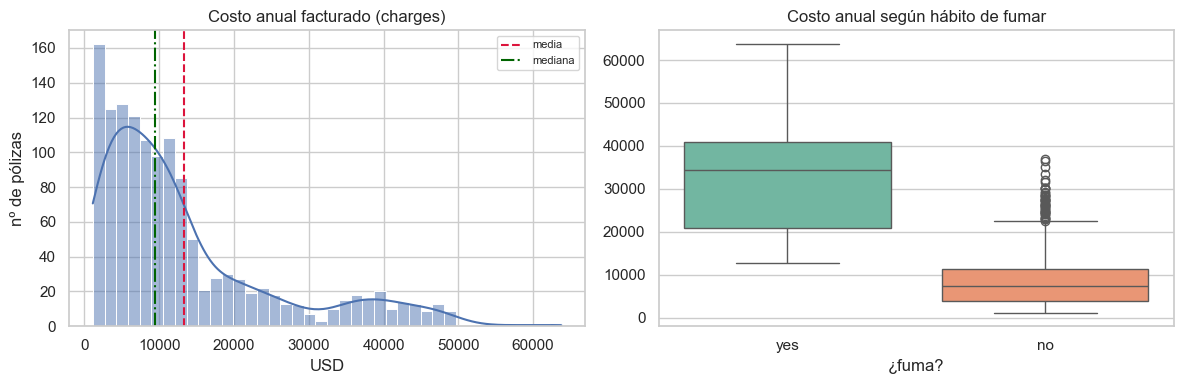

No fumadores:     8,434 USD de media
Fumadores   :    32,050 USD de media  ->  3.8 veces más

Correlación con 'charges':
age         0.299
bmi         0.198
children    0.068


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) La variable objetivo: sesgada a la derecha (media > mediana)
sns.histplot(data["charges"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(data["charges"].mean(), color="crimson", ls="--", label="media")
axes[0].axvline(data["charges"].median(), color="darkgreen", ls="-.", label="mediana")
axes[0].set_title("Costo anual facturado (charges)")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("nº de pólizas")
axes[0].legend(fontsize=8)

# (b) El factor dominante: fumar
sns.boxplot(data=data, x="smoker", y="charges", ax=axes[1], palette="Set2")
axes[1].set_title("Costo anual según hábito de fumar")
axes[1].set_xlabel("¿fuma?")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Los mismos resultados en números
medias = data.groupby("smoker")["charges"].mean()
print(f"No fumadores: {medias['no']:>9,.0f} USD de media")
print(f"Fumadores   : {medias['yes']:>9,.0f} USD de media  ->  {medias['yes'] / medias['no']:.1f} veces más")
print("\nCorrelación con 'charges':")
print(data.select_dtypes('number').corr()["charges"].drop("charges").sort_values(ascending=False).round(3).to_string())


### 1.3 Conclusiones del vistazo

| Hallazgo | Evidencia | Implicación |
|---|---|---|
| **Fumar es el factor dominante** | los fumadores cuestan **3.8× más** (32 050 vs 8 434 USD) | `smoker` será la variable más importante |
| **Efecto no lineal** | los fumadores con IMC alto se disparan; los no fumadores apenas varían | hacen falta modelos de **árboles**, no una recta |
| **Objetivo sesgado** | media 13 270 > mediana 9 380 USD | usar **MAE**; comparar contra la media |

Y un aviso metodológico: los grupos pequeños (`children` con 4–5 hijos tiene 25 y 18 casos)
**no son fiables**; no conviene sacar conclusiones de ahí.


## 2. Configurar el experimento

### 2.1 Qué es un "experimento" en PyCaret

En PyCaret 3.x el experimento se inicializaba con `setup(data, target=...)`, una función
que *no devolvía* nada útil: creaba un **estado global oculto**.

En **4.0** los parámetros se pasan al **constructor** de `RegressionExperiment` y
`.fit(data)` los aplica. El objeto `exp` **es** el estado del experimento: guarda el
preprocesamiento, la partición de datos y los resultados.

`.fit()` hace tres cosas por detrás:

1. **Separa** entrenamiento y prueba según `train_size` (aquí 80 % / 20 %).
2. **Preprocesa** si `preprocess=True` (valor por defecto):
   - imputa valores faltantes (`SimpleImputer`),
   - **codifica las categóricas** (`sex`, `smoker`, `region` → columnas numéricas),
   - escala las numéricas cuando el modelo lo necesita.
3. **Prepara la validación cruzada** con `fold` pliegues (aquí 5).

### 2.2 Los parámetros que usamos

| Parámetro | Valor | Por qué |
|---|---|---|
| `target` | `"charges"` | Es la variable continua que queremos predecir (obligatorio). |
| `session_id` | `123` | Semilla: hace que **todo** sea reproducible (mismo resultado siempre). |
| `train_size` | `0.8` | 80 % para entrenar; el 20 % restante queda intacto como prueba. |
| `fold` | `5` | 5 pliegues de validación cruzada: un buen equilibrio entre coste y estabilidad. |
| `preprocess` | `True` | Codifica el texto y escala: imprescindible con variables categóricas. |
| `verbose` | `False` | Salida limpia; el propio objeto informa con `.X_train`, `.metrics`, etc. |

> 🔴 **Recuerda**: los pliegues se configuran **aquí**, no en `compare_models()`. Pasar
> `compare_models(fold=5)` rompe en la 4.0a8 (ver sección 3).

### 2.3 El contrato del experimento

Después de `.fit(data)` tenemos acceso a las piezas que usaremos en todo el cuaderno:

| Atributo | Qué contiene |
|---|---|
| `exp.X_train`, `exp.y_train` | Datos de entrenamiento **ya preprocesados**. |
| `exp.X_test`, `exp.y_test` | Datos de prueba que quedaron apartados y no se tocan hasta la sección 6. |
| `exp.compare_models()` | Ranking de modelos por validación cruzada. |
| `exp.create_model(id)` | Un modelo concreto entrenado dentro del experimento. |


In [5]:
from pycaret.tasks import RegressionExperiment

exp = RegressionExperiment(
    target="charges",   # variable continua que queremos predecir
    session_id=123,     # semilla: todo el cuaderno es reproducible
    train_size=0.8,     # 80 % para entrenar / 20 % reservado para prueba
    fold=5,             # validación cruzada de 5 pliegues
    preprocess=True,    # imputar, codificar categóricas y escalar
    verbose=False,      # salida limpia
).fit(data)

print("Entrenamiento:", exp.X_train.shape)
print("Prueba       :", exp.X_test.shape)
print("\nVariables de entrada:", list(exp.X_train.columns))
print("La codificación de texto y el escalado viven dentro del pipeline,")
print("no en X_train: por eso siguen siendo las 6 columnas originales.")


Entrenamiento: (1070, 6)
Prueba       : (268, 6)

Variables de entrada: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
La codificación de texto y el escalado viven dentro del pipeline,
no en X_train: por eso siguen siendo las 6 columnas originales.


## 3. Comparar modelos: la línea base

### 3.1 Qué hace `compare_models()`

Entrena y evalúa una familia de modelos con validación cruzada (el preprocesamiento se
aplica **dentro** de cada pliegue, así que no hay fuga de información) y los ordena por RMSE.
Devuelve un `CompareResult` con:

| Atributo | Contenido |
|---|---|
| `.leaderboard` | Tabla comparativa con todas las métricas. |
| `.best` | El `Pipeline` ganador, ya entrenado. |
| `.ranked_ids` | Identificadores ordenados de mejor a peor. |

**Qué comparamos**: `lr` y `ridge` (lineales, solo **suman** efectos), `knn` (instancias),
`dt` (un árbol), `rf` y `et` (ensambles de árboles) y `gbr` (boosting, encadena
correcciones). Con `include=[...]` limitamos la comparación a 7 modelos: el cuaderno corre en
segundos; sin `include` compara los 24 del catálogo (más lento y con muchos avisos de
LightGBM en pantalla).

### 3.2 Cómo se lee la tabla

Cada fila es un modelo y cada columna una métrica de validación cruzada:

| Métrica | Significado | ¿Mejor bajo o alto? |
|---|---|---|
| `MAE` | error absoluto medio, **en USD** | más bajo |
| `RMSE` | error cuadrático medio (raíz), **en USD** | más bajo |
| `R2` | proporción de varianza explicada | más alto (1 = perfecto) |
| `RMSLE` / `MAPE` | error en escala relativa | más bajo |

> **Truco**: como el RMSE está en dólares, se compara con la media de `charges`
> (≈ 13 270 USD). Un RMSE de 4 800 USD es ≈ 36 % de la media.

> 🔴 **Errores conocidos (4.0a8).** (1) `errors="ignore"` es el valor por defecto: un modelo
> que falla desaparece del ranking **en silencio** (y si fallan todos, la tabla sale vacía sin
> ningún mensaje) → usa `errors="raise"`. (2) Los pliegues se configuran en el **constructor
> del experimento**: `compare_models(fold=5)` lanza
> `AttributeError: 'int' object has no attribute 'split'`.


In [6]:
# Modelos disponibles para regresión y sus identificadores (lo que se pasa a include=)
modelos = exp.list_models()
print(f"Modelos disponibles: {len(modelos)}")
print([m.id for m in modelos])


Modelos disponibles: 26
['lr', 'lasso', 'ridge', 'en', 'lar', 'llar', 'omp', 'br', 'ard', 'par', 'ransac', 'tr', 'huber', 'kr', 'svm', 'knn', 'dt', 'rf', 'et', 'ada', 'gbr', 'mlp', 'xgboost', 'lightgbm', 'catboost', 'dummy']


In [7]:
resultado = exp.compare_models(
    include=["lr", "ridge", "knn", "dt", "rf", "et", "gbr"],
    turbo=True,       # rejilla reducida de hiperparámetros -> rápido
    errors="raise",   # 🔴 por defecto es "ignore" y esconde los fallos
    verbose=False,
)

print("Modelo ganador:", resultado.ranked_ids[0])
print("Ranking completo:", resultado.ranked_ids)
resultado.leaderboard.round(4)


Modelo ganador: gbr
Ranking completo: ['gbr', 'rf', 'et', 'lr', 'ridge', 'dt', 'knn']


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,gbr,2732.6656,2.328962e+07,4808.8518,0.8389,0.4558,0.3352
1,rf,2901.0747,2.665502e+07,5156.8514,0.8156,0.4892,0.3504
2,et,2937.1152,3.010845e+07,5481.0489,0.7908,0.5220,0.3742
3,lr,4305.1364,3.856371e+07,6202.5340,0.7333,0.5917,0.4446
4,ridge,4317.6998,3.856803e+07,6202.7975,0.7333,0.5711,0.4468
5,dt,3287.5979,4.715435e+07,6859.6878,0.6740,0.5727,0.4374
6,knn,8232.6923,1.376797e+08,11727.3594,0.0476,0.8761,0.9871


### 3.4 Interpretación del ranking (resultados)

Con `session_id=123` y 5 pliegues, este es el orden que produce la celda anterior
(todas las cifras en USD):

| Modelo | Familia | MAE | RMSE | R² | Lectura |
|---|---|---|---|---|---|
| **gbr** | boosting | **2 733** | **4 809** | **0.839** | gana: corrige errores de forma secuencial |
| `rf` | ensemble de árboles | 2 901 | 5 157 | 0.816 | muy cerca del ganador |
| `et` | ensemble de árboles | 2 937 | 5 481 | 0.791 | algo peor: sus cortes son más aleatorios |
| `dt` | árbol | 3 288 | 6 860 | 0.674 | un árbol solo se sobreajusta y generaliza peor |
| `lr` | lineal | 4 305 | 6 203 | 0.733 | capta la tendencia, no las interacciones |
| `ridge` | lineal regularizado | 4 318 | 6 203 | 0.733 | igual que `lr`: la penalización no aporta aquí |
| `knn` | instancias | 8 233 | 11 727 | 0.048 | **fracasa**: no explica prácticamente nada |

**Cuatro conclusiones**

1. **Los árboles ganan a la recta**: 4 809 vs 6 203 USD de RMSE → ≈ **22 % menos error**.
   La causa ya la vimos en el análisis exploratorio: la relación `smoker × bmi` es no
   lineal y una recta no puede representarla (solo suma efectos).
2. **Un solo árbol no basta**: `dt` queda por debajo incluso de la regresión lineal. Es el
   ejemplo clásico de modelo con **mucha varianza**: memoriza el entrenamiento.
   Ensamblarlo (`gbr`, `rf`, `et`) arregla el problema.
3. **`knn` es un mal modelo para estos datos** y sirve de advertencia: con variables
   categóricas codificadas y escalas muy distintas, la idea de "vecino más cercano"
   pierde sentido. Un R² de 0.05 equivale a no explicar nada.
4. **Ojo con el sesgo de selección**: este ranking es validación cruzada *sobre
   entrenamiento*. Usarlo para **elegir** es correcto; usarlo para **reportar** el
   desempeño final, no (ver sección 6).

> **Regla de oro**: compara siempre contra un punto de referencia. Un modelo que
> predice la media tendría un RMSE ≈ 12 000 USD (lo comprobaremos en la sección 6).
> Frente a eso, 4 809 USD es un buen resultado.


## 4. Crear y ajustar el mejor modelo

`compare_models()` dio una primera impresión con hiperparámetros por defecto. Ahora
trabajamos con un modelo concreto:

| Verbo | Devuelve | Para qué sirve |
|---|---|---|
| `exp.create_model(id)` | `CreateResult` con `.pipeline`, `.metrics`, `.params` | entrenar **un** modelo y ver su validación cruzada pliegue a pliegue |
| `exp.tune_model(est, ...)` | `TuneResult` con `.pipeline`, `.best_params`, `.metrics` | buscar mejores hiperparámetros |

> 🔴 **La regla más importante de la 4.0.** `create_model()` **no** devuelve un estimador,
> devuelve un `CreateResult` (una *dataclass* con el pipeline, las métricas y los
> parámetros). Si se lo pasas tal cual a `tune_model()` obtienes:
>
> ```text
> TypeError: `estimator` must be a registry ID string or an object with .fit / .predict methods.
> ```
>
> **Solución**: pasar el pipeline → `exp.tune_model(creado.pipeline, ...)`. La misma regla
> vale para `predict_model()`, `plot_model()` y `save_model()`.

Ajustamos con `custom_grid={...}` y `optimize="MAE"` (la métrica más interpretable para el
negocio). La rejilla debe contener hiperparámetros **del modelo elegido** (`gbr`):
`n_estimators` (cuántos árboles encadena), `learning_rate` (cuánto corrige cada árbol nuevo)
y `max_depth` (profundidad: a más profundidad, más interacciones posibles).

> 🔴 **Error conocido (4.0a8).** `tune_model()` **sin** `custom_grid` revienta dentro de
> `RandomizedSearchCV` con `ValueError: high is out of bounds for int32` en modelos con
> espacios de búsqueda enormes (por ejemplo LightGBM). Con `custom_grid` no ocurre.


In [8]:
# Tomamos el ganador del ranking y lo entrenamos por separado.
# Así podemos inspeccionar sus métricas pliegue a pliegue antes de ajustarlo.
mejor_id = resultado.ranked_ids[0]

creado = exp.create_model(mejor_id, verbose=False)

print("Modelo elegido :", mejor_id)
print("Clase del pipeline:", type(creado.pipeline[-1]).__name__)
print("\nMétricas de validación cruzada (USD):")
creado.metrics.round(2)


Modelo elegido : gbr
Clase del pipeline: GradientBoostingRegressor

Métricas de validación cruzada (USD):


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold 0,2432.91,17871212.58,4227.44,0.88,0.43,0.30
Fold 1,2772.50,26429280.44,5140.94,0.81,0.47,0.34
Fold 2,2742.84,24333363.47,4932.89,0.83,0.42,0.31
Fold 3,3083.40,27990357.44,5290.59,0.82,0.51,0.41
Fold 4,2631.67,19823904.00,4452.40,0.86,0.45,0.32
Mean,2732.67,23289623.59,4808.85,0.84,0.46,0.34
Std,212.02,3857826.51,405.67,0.03,0.03,0.04


**Cómo leer la tabla de validación cruzada**

La tabla tiene **una fila por pliegue** (`Fold 0` … `Fold 4`) y dos filas resumen:

- **`Mean`**: el desempeño promedio. Es la cifra que se compara con el leaderboard (deben
  coincidir: 2 733 USD de MAE).
- **`Std`**: la **estabilidad**. Un `Std` alto en `RMSE` significa que el modelo acierta
  de forma desigual según qué datos le toquen; es una señal de fragilidad.

Presta atención a la **diferencia entre MAE y RMSE**:

- Si `RMSE` es mucho mayor que `MAE` (aquí 4 809 vs 2 733, un 76 % más), hay **errores
  grandes** en unas pocas pólizas: el RMSE los castiga al cuadrado. Coincide con el
  sesgo de la variable objetivo que vimos en la sección 1.
- Un modelo con errores "uniformes" tendría `RMSE ≈ MAE`.

Este diagnóstico sugiere que el modelo se equivoca sobre todo en las pólizas **caras**
(fumadores con IMC alto). Lo confirmaremos en el análisis de errores de la sección 6.5.


In [9]:
# Búsqueda de hiperparámetros.
# 🔴 tune_model necesita un ESTIMADOR: se le pasa el .pipeline de `creado`,
#    no el CreateResult completo.
ajustado = exp.tune_model(
    creado.pipeline,
    custom_grid={                    # rejilla explícita (evita el bug del int32)
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, None],
    },
    n_iter=10,                       # nº de combinaciones aleatorias a probar
    optimize="MAE",                  # métrica que queremos minimizar (USD)
    verbose=False,
)

print("Mejores hiperparámetros encontrados:", ajustado.best_params)
print("\nMétricas de validación cruzada tras el ajuste (USD):")
ajustado.metrics.round(2)


Mejores hiperparámetros encontrados: {'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.05}

Métricas de validación cruzada tras el ajuste (USD):


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold 0,2426.61,18165307.11,4262.08,0.88,0.42,0.27
Fold 1,2709.51,25088114.03,5008.80,0.82,0.48,0.31
Fold 2,2799.79,23411171.25,4838.51,0.83,0.42,0.30
Fold 3,2857.76,26210762.65,5119.64,0.83,0.45,0.33
Fold 4,2600.61,19122419.95,4372.92,0.86,0.44,0.32
Mean,2678.86,22399555.00,4720.39,0.84,0.44,0.31
Std,153.18,3207662.40,342.73,0.02,0.02,0.02


In [10]:
# ¿Cuánto mejoró realmente el modelo? Comparación pliegue a pliegue del MAE
comparacion_tuning = pd.DataFrame(
    {
        "antes (create_model)": creado.metrics["MAE"],
        "después (tune_model)": ajustado.metrics["MAE"],
    }
)
comparacion_tuning["mejora"] = (
    comparacion_tuning["antes (create_model)"] - comparacion_tuning["después (tune_model)"]
)

print("MAE por pliegue (USD), antes y después de ajustar hiperparámetros:")
comparacion_tuning.round(2)


MAE por pliegue (USD), antes y después de ajustar hiperparámetros:


,antes (create_model),después (tune_model),mejora
Fold 0,2432.91,2426.61,6.30
Fold 1,2772.50,2709.51,62.99
Fold 2,2742.84,2799.79,-56.95
Fold 3,3083.40,2857.76,225.64
Fold 4,2631.67,2600.61,31.06
Mean,2732.67,2678.86,53.81
Std,212.02,153.18,58.84


**Interpretación del ajuste (resultados)**

- Hiperparámetros elegidos: **`n_estimators=300`, `learning_rate=0.05`, `max_depth=2`**. Que
  `max_depth` sea tan bajo es revelador: con **interacciones simples** ya se captura casi
  todo, y el modelo gana interpretabilidad y evita el sobreajuste.
- La mejora del MAE es **pequeña**: 2 732.67 → 2 678.86 USD (≈ 54 USD, un 2 %), y en el
  `Fold 2` incluso empeora 57 USD. Lo que sí baja es la **dispersión** (`Std`: 212 → 153): el
  modelo ajustado es más *parejo* entre particiones.
- Conclusión: con 1 338 filas y una señal tan fuerte, el ajuste fino **estabiliza**, no
  transforma.

> **Esfuerzo frente a beneficio**: elegir bien la **familia** aportó ≈ 22 % de mejora
> (lineal → árboles); ajustar hiperparámetros, ≈ 2 %. Optimiza primero la familia y la
> representación de las variables.
>
> **Para mejorar más**: `transformation=True` en el experimento, crear la variable
> `fumador_imc = smoker × bmi` (la interacción detectada), ensamblar modelos (sección 5) o
> activar `feature_selection=True`.


## 5. Ensamblar modelos

Un *ensemble* combina varios modelos para reducir el error de uno solo:

| Verbo | Idea | Cuándo brilla |
|---|---|---|
| `ensemble_model(est, method="Bagging")` | muchas copias del modelo sobre muestras bootstrap, promediadas | reduce la **varianza** |
| `ensemble_model(est, method="Boosting")` | modelos encadenados que corrigen el error anterior | reduce el **sesgo** |
| `blend_models([...])` | combina las predicciones de modelos distintos | modelos con sesgos diferentes |
| `stack_models([...])` | un **meta-modelo** aprende a combinar los anteriores | cuando el promedio no basta |

Partimos del **árbol simple** (`dt`, el peor de los árboles en la sección 3) y lo ensamblamos;
después combinamos el `gbr` ajustado con el árbol. Todo se compara por RMSE de validación
cruzada (USD), con el `gbr` ajustado como columna de referencia.


In [11]:
# Un árbol de decisión simple, como punto de partida para ensamblar
dt = exp.create_model("dt", verbose=False)

# Bagging (método por defecto) y Boosting sobre el mismo árbol
bagging = exp.ensemble_model(dt.pipeline, n_estimators=20, verbose=False)
boosting = exp.ensemble_model(dt.pipeline, method="Boosting", n_estimators=20, verbose=False)

# Combinaciones de dos modelos distintos
blend = exp.blend_models([creado.pipeline, dt.pipeline], verbose=False)
stack = exp.stack_models([creado.pipeline, dt.pipeline], verbose=False)

# Comparación directa por RMSE (USD) en validación cruzada
pd.DataFrame(
    {
        "árbol simple": dt.metrics["RMSE"],
        "bagging (20)": bagging.metrics["RMSE"],
        "boosting (20)": boosting.metrics["RMSE"],
        "blend (gbr+dt)": blend.metrics["RMSE"],
        "stack (gbr+dt)": stack.metrics["RMSE"],
        "gbr ajustado": ajustado.metrics["RMSE"],
    }
).loc[["Fold 0", "Fold 1", "Fold 2", "Fold 3", "Fold 4", "Mean", "Std"]].round(1)


,árbol simple,bagging (20),boosting (20),blend (gbr+dt),stack (gbr+dt),gbr ajustado
Fold 0,6769.0,4840.2,5129.8,4959.9,4218.2,4262.1
Fold 1,6341.2,5281.1,5233.1,5311.6,5109.7,5008.8
Fold 2,6877.5,5310.7,5457.1,5543.0,4957.3,4838.5
Fold 3,7301.9,5636.9,6405.1,5780.1,5286.0,5119.6
Fold 4,7008.9,5154.6,6429.0,5248.6,4462.1,4372.9
Mean,6859.7,5244.7,5730.8,5368.6,4806.7,4720.4
Std,314.7,257.4,570.3,277.3,402.3,342.7


**Interpretación de los ensambles (resultados)**

RMSE medio (USD): `dt` 6 859.7 → `bagging` **5 244.7** → `boosting` 5 730.8 →
`blend` 5 368.6 → `stack` **4 806.7** → `gbr` ajustado **4 720.4**.

1. **Ensamblar un árbol lo mejora de inmediato**: el bagging recorta el RMSE un 24 %.
2. **Aquí el bagging supera al boosting** (5 245 vs 5 731): no hay receta universalmente
   mejor; con otro `n_estimators` el orden puede cambiar (reto extra del ejercicio).
3. El `stack` es el mejor de los ensambles (4 807), pero **no supera al `gbr` ajustado**
   (4 720): combinar ayuda cuando los modelos son parecidos en calidad y **distintos en sus
   errores**.
4. La estabilidad es mixta: bagging y blend reducen la dispersión respecto al árbol
   (Std 315 → 257 y 277); boosting y stack la aumentan (570 y 402).

> **Conclusión**: el modelo de trabajo sigue siendo el `gbr` ajustado. Ensamblar **no** es una
> mejora automática: hay que medirla, y la medición que importa es la del conjunto de prueba.


## 6. Evaluar el modelo en datos no vistos

Todo lo anterior fue **validación cruzada sobre entrenamiento**: sirve para *elegir*, no para
*reportar* (si reportamos esa métrica, medimos el modelo en los mismos datos con los que lo
seleccionamos). La estimación honesta se hace sobre el **20 % que el experimento apartó** y
que ningún modelo ha visto.

`exp.predict_model(est.pipeline)` sin `data` evalúa en ese conjunto de prueba y devuelve un
`PredictResult` con `.predictions` (tabla original + columna **`prediction_label`**) y
`.metrics`.

> 🔴 **Error conocido (4.0a8).** `PredictResult.metrics` lanza
> `TypeError: Expected numeric dtype, got object instead` porque la tabla conserva la columna
> objetivo. Mientras se corrige, calculamos las métricas con `sklearn.metrics` sobre
> `.predictions` (lo mismo que hace PyCaret por dentro).

**Cómo se leen las métricas.** `MAE` = "en promedio me equivoco en X dólares" (la más
interpretable). `RMSE` castiga más los errores grandes. `R²` = 1 es perfecto, 0 es igual que
predecir la media. Y siempre hay que comparar contra una **referencia**: aquí, predecir la
media del entrenamiento.


In [12]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 🔴 `ajustado` es un TuneResult: a predict_model hay que pasarle su .pipeline
prueba = exp.predict_model(ajustado.pipeline, verbose=False)

y_real = prueba.predictions["charges"]
y_pred = prueba.predictions["prediction_label"]

mae = mean_absolute_error(y_real, y_pred)
rmse = root_mean_squared_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

# Referencia obligatoria: predecir siempre la media del entrenamiento
media = np.full(len(y_real), exp.y_train.mean())
mae_media = mean_absolute_error(y_real, media)

print(f"Pólizas evaluadas: {len(y_real)} (el 20 % que el modelo nunca vio)\n")
print("--- Nuestro modelo (gbr ajustado) ---")
print(f"  MAE  : {mae:>10,.2f} USD   ({mae / y_real.mean():.1%} del costo medio)")
print(f"  RMSE : {rmse:>10,.2f} USD")
print(f"  R²   : {r2:>10.4f}")
print("\n--- Referencia: predecir siempre la media ---")
print(f"  MAE  : {mae_media:>10,.2f} USD   ({mae_media / y_real.mean():.1%} del costo medio)")
print(f"\nEl modelo reduce el error medio un {(1 - mae / mae_media):.0%} frente a no modelar nada.")


Pólizas evaluadas: 268 (el 20 % que el modelo nunca vio)

--- Nuestro modelo (gbr ajustado) ---
  MAE  :   2,212.41 USD   (16.3% del costo medio)
  RMSE :   3,714.20 USD
  R²   :     0.9098

--- Referencia: predecir siempre la media ---
  MAE  :   9,075.34 USD   (66.8% del costo medio)

El modelo reduce el error medio un 76% frente a no modelar nada.


**Interpretación del desempeño en prueba (resultados)**

| Pregunta de negocio | Respuesta |
|---|---|
| ¿Se puede predecir el costo? | **Sí**: R² ≈ 0.91 en datos no vistos |
| ¿Cuánto error cometemos? | MAE ≈ 2 212 USD; RMSE ≈ 3 714 USD |
| ¿Es aceptable? | Es ≈ 16 % del costo medio: útil para tarificar |
| ¿Aporta el modelo? | Reduce el error medio un **76 %** frente a predecir la media (9 075 USD) |

Dos lecturas técnicas: el desempeño en prueba es algo **mejor** que en validación cruzada
(2 212 vs 2 679) porque esta partición concreta resultó más "fácil"; y el `RMSE` sigue siendo
un 68 % mayor que el `MAE`, lo que indica errores grandes en unas pocas pólizas caras. Por eso
el siguiente paso es **analizar los errores por grupo**.


In [13]:
# Predicciones fila a fila: valor real vs. predicción (columnas originales + 'prediction_label')
prueba.predictions[["age", "bmi", "smoker", "charges", "prediction_label"]].head(10).round(2)


,age,bmi,smoker,charges,prediction_label
650,49,42.68,no,9800.89,10906.59
319,32,37.34,no,4667.61,7507.14
314,27,31.40,yes,34838.87,35602.53
150,35,24.13,no,5125.22,7249.90
336,60,25.74,no,12142.58,14819.83
970,50,28.16,no,10702.64,11287.90
169,27,18.90,no,4827.90,5181.44
684,33,18.50,no,4766.02,5329.94
1097,22,33.77,no,1674.63,2975.34
512,51,22.42,no,9361.33,12236.78


In [14]:
# Diagnóstico 1 — residuos: ¿los errores son ruido aleatorio o queda un patrón?
# Si hay patrón (curva, embudo), al modelo le falta información o le sobra rigidez.
# 🔴 plot_model también recibe el .pipeline, no el TuneResult
exp.plot_model(ajustado.pipeline, plot="residuals")


In [15]:
# Diagnóstico 3 — importancia de cada variable (permutación sobre el pipeline completo)
# Se mide cuánto empeora el modelo al desordenar cada variable.
exp.plot_model(ajustado.pipeline, plot="feature")


### 6.4 Diagnóstico y análisis de errores

Los gráficos de PyCaret sirven para **mirar** el modelo; las tablas, para **cuantificarlo**:

- **`residuals`**: la nube se concentra alrededor de 0 sin curvas ni embudos. Un patrón
  (curva o embudo) indicaría que al modelo le falta información o le sobra rigidez.
- **`feature`**: el orden de importancia es **`smoker` ≫ `sex` > `age` > `bmi` > `region` >
  `children`**, coherente con el vistazo de la sección 1.3: fumar manda.

Después medimos el error por grupo (fumador y tramos de IMC) y revisamos las pólizas peor
predichas.


In [16]:
# Análisis de errores por grupo: ¿el modelo se equivoca más en algún subgrupo?
analisis = prueba.predictions.assign(
    error=lambda d: d["prediction_label"] - d["charges"],           # con signo: detecta sesgo
    error_abs=lambda d: (d["prediction_label"] - d["charges"]).abs(),  # magnitud
)

print("Error (USD) según hábito de fumar:")
print(
    analisis.groupby("smoker")[["error", "error_abs"]]
    .agg(["mean", "count"])
    .round(0)
    .to_string(),
    "\n",
)

tramos_imc = pd.cut(analisis["bmi"], bins=[0, 25, 30, 35, 100],
                    labels=["<25", "25-30", "30-35", ">35"])
print("Error absoluto medio (USD) por tramos de IMC:")
print(
    analisis.groupby(tramos_imc, observed=True)["error_abs"]
    .agg(["mean", "count"])
    .round(0)
    .to_string(),
    "\n",
)

print("Las 5 pólizas peor predichas:")
analisis.nlargest(5, "error_abs")[
    ["age", "bmi", "smoker", "charges", "prediction_label", "error"]
].round(0)


Error (USD) según hábito de fumar:
        error       error_abs      
         mean count      mean count
smoker                             
no      656.0   208    2145.0   208
yes    -468.0    60    2447.0    60 

Error absoluto medio (USD) por tramos de IMC:
         mean  count
bmi                 
<25    1905.0     57
25-30  2648.0     70
30-35  2035.0     76
>35    2221.0     65 

Las 5 pólizas peor predichas:


,age,bmi,smoker,charges,prediction_label,error
1027,23,19.0,no,21595.0,2649.0,-18946.0
524,42,26.0,yes,38246.0,20889.0,-17356.0
543,54,47.0,yes,63770.0,46698.0,-17072.0
476,24,28.0,yes,35148.0,18946.0,-16202.0
696,53,32.0,no,29186.0,14230.0,-14957.0


**Interpretación del análisis de errores (resultados)**

- **Sesgo con dirección clara**: el modelo **sobreestima** a los no fumadores (error medio
  **+656 USD**) y **subestima** a los fumadores (**−468 USD**). El sesgo global es ≈ +400 USD
  sobre un MAE de 2 212 (18 %): moderado, no despreciable.
- **El error absoluto es algo mayor en fumadores** (2 447 vs 2 145 USD), pero la diferencia es
  **modesta** (14 %): no es cierto que el modelo "solo falle con fumadores".
- **Por tramos de IMC el error no crece de forma monótona**: el tramo 25–30 es el de mayor
  error (2 648 USD) y el <25 el mejor (1 905 USD).
- **Las 5 pólizas peor predichas son todas subestimaciones** de costos altos. El peor caso:
  23 años, IMC 19, **no fumador**, costo real 21 595 USD y predicción 2 649 USD. Ninguna
  variable de la tabla explica ese costo (probablemente una enfermedad previa no registrada):
  **ese es el techo de estos datos**.

**Consecuencias prácticas**: (1) al tarificar, añade un **margen de seguridad** y revisa a mano
los perfiles de costo alto; (2) como el sesgo va en direcciones opuestas por grupo, un modelo
**separado por grupo** (`smoker`) lo reduciría; (3) para mejorar de verdad, **añadir datos**
(historial médico) rinde más que complicar el algoritmo.


## 7. Predecir datos nuevos (producción)

Un modelo no se guarda para lucirlo: se usa para puntuar **registros que nunca vio**. Aquí
simulamos el caso típico: llega un lote de solicitudes y hay que estimar cuánto costará cada
póliza.

Se pasa un `DataFrame` al argumento `data`. El pipeline aplica el **mismo preprocesamiento**
que aprendió durante el entrenamiento (codificación de categóricas, escalado), así que no hay
que preparar los datos a mano. El `DataFrame` nuevo debe tener **las mismas columnas
explicativas** que el entrenamiento (puede no tener la columna objetivo).


In [17]:
# Simulamos 5 solicitudes nuevas: filas reales SIN la columna objetivo
# (el modelo no debe ver nunca el costo real, eso es lo que queremos predecir).
nuevas_polizas = data.drop(columns=["charges"]).sample(5, random_state=7)
nuevas_polizas


,age,sex,bmi,children,smoker,region
13,56,female,39.82,0,no,southeast
1052,49,male,29.83,1,no,northeast
172,18,male,15.96,0,no,northeast
1085,39,female,18.30,5,yes,southwest
683,53,male,24.32,0,no,northwest


In [18]:
# 🔴 de nuevo: .pipeline
predicciones_nuevas = exp.predict_model(
    ajustado.pipeline, data=nuevas_polizas, verbose=False
).predictions

# La tabla de salida trae las variables originales + 'prediction_label'
predicciones_nuevas[["age", "bmi", "smoker", "prediction_label"]].round(2)

# Comparación con la alternativa "sin modelo": cobrar siempre la media
print(f"Costo medio del entrenamiento: {exp.y_train.mean():,.0f} USD")
print("Prima estimada para estas 5 pólizas:")
print(predicciones_nuevas["prediction_label"].round(0).tolist())


Costo medio del entrenamiento: 13,189 USD
Prima estimada para estas 5 pólizas:
[11922.0, 11144.0, 1332.0, 18379.0, 12567.0]


**Interpretación de las predicciones nuevas (resultados)**

- La primera póliza (56 años, IMC 39.8, **no fumador**) recibe una prima estimada de
  ≈ 11 900 USD.
- La cuarta (39 años, IMC 18.3, **fumador**) recibe ≈ 18 400 USD: el modelo aplica el
  efecto de fumar, incluso con un IMC bajo.
- La tercera (18 años, IMC 16.0, no fumador) recibe ≈ 1 300 USD: el perfil más barato.
- Compara con la alternativa ingenua de cobrar **siempre la media** (≈ 13 270 USD):
  el modelo **personaliza**. Esa diferencia es el valor de negocio del ejercicio: cobrar
  lo mismo a todos los perfiles es subsidiar al fumador con el recargo del sano.

> **Precaución de uso**: cada predicción viene con el error típico del modelo
> (RMSE ≈ 3 700 USD). Por eso, en producción, se usan **bandas** (predicción ± error) y no
> cifras exactas.


## 8. Guardar y recuperar el modelo

`pycaret.save_model()` serializa el **pipeline completo** (preprocesamiento + estimador) en un
único `.pkl`. Guardar solo el estimador sería un error: sin la codificación de categóricas que
aprendió, no sabría qué hacer con `"yes"` o `"female"`. Eso permite reproducir, desplegar y
versionar el modelo.

`pycaret.load_model(ruta)` devuelve un `Pipeline` de scikit-learn listo para `.predict()`. La
comprobación que haremos es la clave de la sección: el modelo recargado debe dar
**exactamente** las mismas predicciones.

> 🔴 **Error conocido (4.0a8).** `exp.save_experiment(...)` (guardar el experimento completo)
> falla con `PicklingError` porque no puede serializar una función lambda interna. Guarda solo
> el modelo y reproduce el experimento con el código más la semilla (`session_id`).


In [19]:
from pathlib import Path

from pycaret import load_model, save_model

Path("artifacts").mkdir(exist_ok=True)

# 🔴 se guarda el .pipeline (el modelo), no el TuneResult
ruta = save_model(ajustado.pipeline, "artifacts/pycaret_insurance_gbr")
print("Modelo guardado en:", ruta)
print("Tamaño del archivo: %.1f KB" % (Path(str(ruta)).stat().st_size / 1024))

recargado = load_model(str(ruta))
print("\nModelo recargado:", type(recargado).__name__)
print("Pasos del pipeline:", list(recargado.named_steps))

# La prueba de fuego: el modelo recargado debe predecir EXACTAMENTE lo mismo
assert np.allclose(recargado.predict(nuevas_polizas), ajustado.pipeline.predict(nuevas_polizas))
print("\n✔ Las predicciones del modelo recargado coinciden con las del original")


Modelo guardado en: C:\Users\CARLOS\Downloads\artifacts\pycaret_insurance_gbr.pkl
Tamaño del archivo: 228.0 KB

Modelo recargado: Pipeline
Pasos del pipeline: ['preprocess', 'gbr']

✔ Las predicciones del modelo recargado coinciden con las del original


In [20]:
# El modelo recargado funciona por sí solo: no necesita el experimento ni PyCaret.
# (Es un Pipeline de scikit-learn: basta con .predict()).
recargado.predict(nuevas_polizas).round(2)


array([11921.74, 11144.49,  1332.43, 18379.11, 12566.88])

## 9. Automatizar el proceso: `automl()` y `finalize_model()`

### 9.1 Las dos últimas piezas

| Función | Qué hace | Cuándo usarla |
|---|---|---|
| `exp.automl()` | Encadena **comparación + ajuste** y devuelve el mejor pipeline sin intervención humana | punto de partida rápido, o para tener una referencia de "hasta dónde se puede llegar" |
| `exp.finalize_model(est)` | Reentrena el pipeline con **todos** los datos disponibles (entrenamiento + prueba) | justo antes de poner el modelo en producción |

### 9.2 Una advertencia que se pasa por alto

`finalize_model()` reentrena con el 100 % de los datos. Eso suele mejorar el modelo (más
datos = mejor), **pero destruye la posibilidad de evaluarlo**: ya no queda ningún dato que
el modelo no haya visto.

> **Regla**: reporta las métricas **antes** de finalizar y finaliza solo cuando ya hayas
> decidido que el modelo sale a producción. El modelo final va acompañado de las métricas
> del modelo *pre-finalización*.

También ojo con el coste: `automl()` con el catálogo completo (24 modelos, con ajuste) tarda
minutos. Con `include=[...]` y `n_iter` pequeño se controla el tiempo.


In [21]:
# automl: compara Y ajusta sin intervención humana.
# Limitamos la lista de modelos y las iteraciones para que el cuaderno no tarde minutos.
mejor = exp.automl(
    optimize="MAE",
    n_iter=5,          # nº de combinaciones probadas por modelo
    turbo=True,        # rejillas reducidas -> más rápido
    include=["lr", "ridge", "dt", "rf", "et", "gbr"],
    verbose=False,
)

ultimo_paso = list(mejor.named_steps)[-1]
print("automl() devuelve:", type(mejor).__name__)
print("Estimador elegido:", ultimo_paso, "->", type(mejor.named_steps[ultimo_paso]).__name__)

# ¿Con qué hiperparámetros? Comparémoslos con los que elegimos nosotros
claves = ("n_estimators", "learning_rate", "max_depth", "min_samples_leaf", "subsample")
print("\nHiperparámetros elegidos por automl():")
print({k: v for k, v in mejor.named_steps[ultimo_paso].get_params().items() if k in claves})
print("Nuestros hiperparámetros (tune_model):")
print(ajustado.best_params)

# Comparamos su desempeño en prueba con el del modelo que construimos a mano
pred_automl = exp.predict_model(mejor, verbose=False).predictions

print("\nMAE en el conjunto de prueba (USD):")
print(f"  automl()             : {mean_absolute_error(pred_automl['charges'], pred_automl['prediction_label']):>10,.2f}")
print(f"  nuestro gbr ajustado : {mae:>10,.2f}")

# Y ahora sí: reentrenamos con TODOS los datos para dejarlo listo para producción
final = exp.finalize_model(mejor)
print("\nModelo final (entrenado con el 100 % de los datos):")
print("  pasos:", list(final.pipeline.named_steps))
print("  ↑ ya no existe conjunto de prueba: las métricas de arriba son las válidas")


automl() devuelve: Pipeline
Estimador elegido: gbr -> GradientBoostingRegressor

Hiperparámetros elegidos por automl():
{'learning_rate': 0.4, 'max_depth': np.int64(7), 'min_samples_leaf': 4, 'n_estimators': np.int64(190), 'subsample': 0.7}
Nuestros hiperparámetros (tune_model):
{'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.05}

MAE en el conjunto de prueba (USD):
  automl()             :   3,962.37
  nuestro gbr ajustado :   2,212.41

Modelo final (entrenado con el 100 % de los datos):
  pasos: ['preprocess', 'gbr']
  ↑ ya no existe conjunto de prueba: las métricas de arriba son las válidas


**Interpretación de la automatización (resultados)**

- `automl()` vuelve a elegir un modelo de **boosting** (`gbr`), lo que confirma que nuestra
  elección manual no era casualidad.
- **Pero aquí llega la sorpresa más útil del cuaderno**: su MAE en el conjunto de prueba es
  **peor** que el nuestro: **3 962 USD** frente a **2 212 USD**.
- La causa está a la vista en los hiperparámetros impresos:

| | `n_estimators` | `learning_rate` | `max_depth` | otros |
|---|---|---|---|---|
| **automl()** | 190 | 0.4 | **7** | `subsample=0.7`, `min_samples_leaf=4` |
| **nosotros** | 300 | 0.05 | **2** | — |

  Árboles de profundidad 7 con tasa de aprendizaje 0.4 son un modelo **mucho más complejo y
  agresivo**. `automl()` optimizó la métrica de **validación cruzada** y encontró una
  combinación que se ajusta muy bien a los pliegues de entrenamiento… pero que **no
  generaliza** igual de bien a la partición de prueba. Es un caso de sobreajuste en la
  *selección*, no en el entrenamiento.

- `finalize_model()` devuelve un pipeline reentrenado con **todos** los datos, listo para
  desplegar. A partir de ahí **no hay métricas honestas**: las válidas son las de antes de
  finalizar.

> **La lección más importante del cuaderno**: `automl()` **no es magia ni exime de medir**.
> Úsalo como punto de referencia y como explorador de familias de modelos, pero **valida
> siempre en el conjunto de prueba** y quédate con tu modelo si es mejor. Reportar "lo que
> eligió AutoML" sin medirlo es exactamente el error que este cuaderno intenta evitar.


## 10. Resumen, equivalencias y errores conocidos

### 10.1 Qué construimos (recapitulación con resultados)

| Paso | Herramienta | Resultado obtenido |
|---|---|---|
| Entender los datos | pandas + seaborn | `smoker` domina el costo (×3.8); interacción con `bmi`; objetivo sesgado (media 13 270 > mediana 9 380) |
| Configurar | `RegressionExperiment(...).fit(data)` | 1 070 filas de entrenamiento / 268 de prueba, 6 variables |
| Comparar | `compare_models(include=[...])` | gana `gbr` (RMSE 4 809 USD, R² 0.839); la recta queda ≈ 22 % peor |
| Ajustar | `tune_model(custom_grid=...)` | `n_estimators=300, learning_rate=0.05, max_depth=2`; MAE 2 733 → 2 679 USD (más estable) |
| Ensamblar | `ensemble_model`, `blend_models`, `stack_models` | mejoran mucho al árbol (6 860 → 5 245 USD), pero no superan al `gbr` |
| Evaluar | `predict_model(ajustado.pipeline)` | MAE 2 212 USD, RMSE 3 714 USD, R² 0.910 (**76 % mejor** que predecir la media) |
| Diagnosticar | `plot_model(..., plot=...)` | residuos sin patrones, cola derecha; `smoker` ≫ `sex` > `age` > `bmi` > `region` > `children` |
| Analizar errores | tablas por grupo | sesgo +656 USD (no fumadores) y −468 (fumadores); las peores predicciones son subestimaciones de costos altos |
| Predecir | `predict_model(..., data=nuevas)` | primas personalizadas por perfil de riesgo |
| Guardar | `save_model` / `load_model` | pipeline completo en `.pkl`, predicciones idénticas |
| Automatizar | `automl()` + `finalize_model()` | elige boosting, pero con **peor MAE en prueba** (3 962 vs 2 212 USD): la automatización no exime de medir |

**El mensaje central**: en este problema, **entender los datos** (que fumar manda y que su
efecto depende del IMC) aportó más que cualquier truco de ajuste. Los modelos sirven para
**confirmar y cuantificar** lo que el análisis exploratorio ya insinuaba.


---

## 11. Ejercicio propuesto

### Parte A — Reproducir y variar

1. **Otra métrica de ajuste.** Repite `tune_model` con `optimize="RMSE"` y compara los
   hiperparámetros elegidos con los que obtuvimos optimizando MAE. ¿Cambian? ¿Por qué?
2. **La interacción detectada.** Crea la columna `fumador_imc = (smoker == "yes").astype(int) * bmi`
   y añádela al conjunto. ¿Mejora el MAE? ¿Qué pasa con la importancia de `smoker`?
3. **Menos variables.** Repite la comparación sin `sex` ni `region`. ¿Empeora el MAE? ¿Cuánto?

### Parte B — Pensar




**Pistas para la Parte B**

- (a) El RMSE eleva el error al cuadrado: lo dominan unas pocas pólizas de costo muy alto.
- (b) El leaderboard es validación cruzada **sobre entrenamiento**: elegir con él contamina la
  estimación (*sesgo de selección*).
- (c) El trabajo manual aportó **comprensión** (sabes qué se probó y por qué) y un modelo que
  aquí generaliza mejor. La automatización es una herramienta, no un veredicto.

</details>
